# Лабораторная работа №2: Реализация продвинутых ансамблевых методов

**Цель работы:**
Реализовать современные ансамблевые алгоритмы машинного обучения и исследовать их эффективность.

## Задачи
1. Реализовать Gradient Boosting с нуля:
   - Градиентный спуск по функциональному пространству
   - Функции потерь: MSE, MAE, Logistic loss
   - Регуляризация: learning rate, subsampling
2. Реализовать упрощённую версию XGBoost:
   - Второй порядок градиентов (Hessian)
   - Регуляризация L1/L2 для листьев
   - Обработка разреженных данных
3. Реализовать Stacking:
   - Базовые алгоритмы разных типов
   - Мета-алгоритм с cross-validation
4. Реализовать Voting классификатор:
   - Hard voting, soft voting
   - Взвешенное голосование
5. Исследовать влияние гиперпараметров:
   - Количество деревьев
   - Глубина деревьев
   - Learning rate
   - Доля выборки (subsample)
6. Провести bias-variance decomposition анализ.
7. Сравнить с реализацией scikit-learn на наборах: Adult, Titanic, Bank Marketing.
8. Проанализировать feature importance и интерпретируемость.

## Источники данных
- Adult (классификация):
  ```
  import io

  import pandas as pd
  import requests

  url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
  resp = requests.get(url, verify=False)
  col_names = [
  'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
  'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
  'hours-per-week', 'native-country', 'income'
  ]

  df = pd.read_csv(io.StringIO(resp.text), names=col_names, sep=',\s', engine='python')
  ```
- Titanic (классификация):
  ```
  import seaborn as sns
  df = sns.load_dataset('titanic')
  ```
- Bank Marketing (классификация):
  ```
  df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.csv', sep=';')
  ```

## Структура отчета
1. **Введение** — цели и описание алгоритмов.
2. **Теория** — математическое обоснование ансамблей.
3. **Реализация** — код (NumPy).
4. **Эксперименты** — исследование гиперпараметров.
5. **Сравнение** — scikit-learn vs ваша реализация.
6. **Интерпретируемость** — анализ feature importance.
7. **Выводы** — рекомендации.

## Критерии оценивания (15 баллов)
- Реализация Gradient Boosting и XGBoost — 6 баллов
- Реализация Stacking и Voting — 4 балла
- Эксперименты и подбор гиперпараметров — 3 балла
- Анализ feature importance и bias-variance — 1 балл
- Качество отчёта и визуализаций — 1 балл

In [1]:
# Импорты
import io
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier, RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score, roc_auc_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from typing import List, Optional
from sklearn.model_selection import GridSearchCV

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
# Признаки и цель
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'alone']
target = 'survived'

X = df[features].copy()
y = df[target].copy()

# Приведём категориальные столбцы к строковому типу (если они category)
categorical_cols = ['embarked', 'class', 'who']
for col in categorical_cols:
    if X[col].dtype.name == 'category':
        X[col] = X[col].astype(object)

# Заполнение пропусков
X['age'] = X['age'].fillna(X['age'].median())
X['fare'] = X['fare'].fillna(X['fare'].median())
X[['embarked', 'class', 'who']] = X[['embarked', 'class', 'who']].fillna('MISSING')

# Кодирование категорий
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

# Преобразование в массивы
X = X.values.astype(np.float64)
y = y.values.astype(np.float64)

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 1. Реализация Gradient Boosting
Реализовать класс `MyGradientBoosting` с методами:
- `fit(self, X, y)`
- `predict(self, X)`

#### 1.1 Реализация регрессинного дерева для задачи градиентного бустинга

**Задача:** минимизация суммы квадратов ошибок (RSS, Residual Sum of Squares):
$$ RSS = \sum_{i=1}^n (y_i - \hat{y}_i)^2 $$

**Идея:** рекурсивно разбивать выборку по наиболее “выгодному” признаку и порогу, чтобы минимизировать ошибку разбиения.

**Критерий разбиения.** Для каждой возможной пары (признак, порог) считаем функцию потерь:
$$Loss = Var_{left} \cdot N_{left} + Var_{right} \cdot N_{right}$$
где Var_left — дисперсия целевой переменной слева, N_left — число объектов слева, аналогично справа. Чем меньше Loss, тем лучше разбиение.

**Остановка:** разбиваем рекурсивно, пока не достигнем максимальной глубины, минимального размера выборки или всё множество в узле стало константным.

**Листовой узел.** Вместо дальнейших разбиений в лист узла записывается среднее значение целевой переменной:
$$ value = \frac{1}{N_{leaf}} \sum_{i=1}^{N_{leaf}} y_i $$

**Предсказание:** для нового объекта спускаемся по дереву согласно условиям split’а, находим лист и возвращаем “value”.

------------------------
- При построении дерева для каждого сплита считаем **снижение MSE**:  
  `gain = total_mse_before - (left_mse + right_mse)`
- Важность признака — сумма `gain × (n_samples_in_node / n_total)` по всем узлам, где он использовался.

In [3]:
class RegressionTree:
    def __init__(self, max_depth=3, min_samples_split=2, random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.random_state = random_state
        self.tree_ = None
        self.feature_importances_ = None
        self.n_features_in_ = None

    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y)
        n_samples, n_features = X.shape
        self.n_features_in_ = n_features
        self.feature_importances_ = np.zeros(n_features)

        self.tree_ = self._build_tree(X, y, depth=0, n_samples_total=n_samples)

        # Нормируем важности (как в sklearn)
        total = self.feature_importances_.sum()
        if total > 0:
            self.feature_importances_ /= total
        else:
            self.feature_importances_ = np.zeros(n_features)
        return self

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._predict_one(x, self.tree_) for x in X])

    def _build_tree(self, X, y, depth, n_samples_total):
        n_samples = len(y)

        # Условия останова
        if (n_samples < self.min_samples_split
            or depth >= self.max_depth
            or np.var(y) == 0):  # все значения одинаковые → лист
            return {'value': float(y.mean())}

        best_feat, best_thresh, best_gain = None, None, -np.inf
        total_mse = np.var(y) * n_samples

        for feat in range(X.shape[1]):
            values = np.unique(X[:, feat])
            if len(values) < 2:
                continue

            thresholds = (values[:-1] + values[1:]) / 2.0
            for t in thresholds:
                left_mask = X[:, feat] <= t
                n_left = left_mask.sum()
                n_right = n_samples - n_left
                if n_left == 0 or n_right == 0:
                    continue

                left_y = y[left_mask]
                right_y = y[~left_mask]
                mse_left = np.var(left_y) * n_left if n_left > 0 else 0
                mse_right = np.var(right_y) * n_right if n_right > 0 else 0
                gain = total_mse - (mse_left + mse_right)

                if gain > best_gain:
                    best_gain = gain
                    best_feat = feat
                    best_thresh = t

        if best_feat is None or best_thresh is None or best_gain <= 0:
            return {'value': float(y.mean())}

        weight = n_samples / n_samples_total
        self.feature_importances_[best_feat] += weight * best_gain

        # Делим данные
        left_mask = X[:, best_feat] <= best_thresh
        left_subtree = self._build_tree(
            X[left_mask], y[left_mask], depth + 1, n_samples_total
        )
        right_subtree = self._build_tree(
            X[~left_mask], y[~left_mask], depth + 1, n_samples_total
        )

        return {
            'feature': best_feat,
            'threshold': best_thresh,
            'left': left_subtree,
            'right': right_subtree
        }

    def _predict_one(self, x, node):
        if 'value' in node:
            return node['value']
        if node['feature'] is None:
            return node.get('value', 0.0)
        if x[node['feature']] <= node['threshold']:
            return self._predict_one(x, node['left'])
        else:
            return self._predict_one(x, node['right'])

**Сравнение моей реализации с sklearn**

In [4]:
# Данные
X, y = make_regression(n_samples=100, n_features=1, noise=5, random_state=42)
X = X.astype(np.float32)

# Мое дерево
tree = RegressionTree(max_depth=3, min_samples_split=2)
tree.fit(X, y)
y_pred = tree.predict(X)

# sklearn дерево для сравнения
sk_tree = DecisionTreeRegressor(max_depth=3, min_samples_split=2, random_state=42)
sk_tree.fit(X, y)
y_pred_sk = sk_tree.predict(X)

# Сравнение ошибок
print("MSE (my tree):", mean_squared_error(y, y_pred))
print("MSE (sklearn):", mean_squared_error(y, y_pred_sk))

MSE (my tree): 40.51922791739078
MSE (sklearn): 40.51922791739078


#### 1.2 Gradient Boosting для регрессии

Алгоритм строится следующим образом:

1) первоначальному прогнозу присваивается среднее значение y_train для всех образцов;

2) рассчитываются остатки модели на основе антиградиента функции потерь;

3) регрессионное дерево обучается на X_train и остатках, далее делается прогноз на X_train;

4) полученный прогноз добавляется к первоначальному и шаги 2-4 повторяются для каждого дерева;

5) после обучения всех моделей снова создаётся первоначальный прогноз из шага 1;

6) далее делаются прогнозы для X_test на обученных деревьях и добавляются к первоначальному;

7) полученная сумма и будет конечным прогнозом.

Функция потерь:
$$L(y_i, F(x_i)) = \frac{1}{2}(y_i - F(x_i))^2$$
Остатки:
$$r_{ik} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F(x) = F_{m-1}(x)} = y_i - F_{m-1}(x_i)$$

*learning_rate* (темп обучения, шаг градиентного спуска) в градиентном бустинге управляет величиной вклада каждого нового дерева в итоговое предсказание:

In [5]:
class MyGBMRegressor:
  def __init__(self, learning_rate=0.1, n_estimators=100,
               max_depth=3, subsample=1.0, random_state=0):
      self.learning_rate = learning_rate
      self.n_estimators = n_estimators
      self.max_depth = max_depth
      self.subsample = subsample
      self.random_state = random_state
      self.trees = []

  def fit(self, X, y):
      rng = np.random.RandomState(self.random_state)

      self.initial_leaf = y.mean()
      predictions = np.full(len(y), self.initial_leaf, dtype=np.float64)

      for _ in range(self.n_estimators):
          residuals = y - predictions

          if self.subsample < 1.0:
              n_samples = int(len(y) * self.subsample)
              indices = rng.choice(len(y), size=n_samples, replace=False)
              X_train = X[indices]
              y_train = residuals[indices]
          else:
              X_train = X
              y_train = residuals

          tree = RegressionTree(max_depth=self.max_depth)
          tree.fit(X_train, y_train)

          predictions += self.learning_rate * tree.predict(X)

          self.trees.append(tree)

  def predict(self, X):
      predictions = np.zeros(len(X)) + self.initial_leaf
      for i in range(self.n_estimators):
          predictions += self.learning_rate * self.trees[i].predict(X)
      return predictions

Сравнение с sklearn

In [6]:
# Мое
my_gbm = MyGBMRegressor(
    learning_rate=0.1,
    n_estimators=100,
    max_depth=3,
    subsample=1.0,
    random_state=0
)
my_gbm.fit(X, y)
y_pred = my_gbm.predict(X)

# sklearn
sk_gbm = GradientBoostingRegressor(
    learning_rate=0.1,
    n_estimators=100,
    max_depth=3,
    subsample=1.0,
    random_state=0,
    criterion='squared_error'
)
sk_gbm.fit(X, y)
y_pred_sk = sk_gbm.predict(X)

# Сравнение ошибок
print("MSE (my gbm):", mean_squared_error(y, y_pred))
print("MSE (sklearn):", mean_squared_error(y, y_pred_sk))

MSE (my gbm): 3.170262831922152
MSE (sklearn): 3.170262831922151


#### 1.3 Gradient Boosting для классификации

Функция потерь:
$$
L(y, F) = \log(1 + e^{F}) - y F
$$
градиент по \( F \) равен:
$$
\frac{\partial L}{\partial F} = \sigma(F) - y \quad \Rightarrow \quad {антиградиент} = y - \sigma(F)
$$

In [7]:
def sigmoid(z):
    z = np.clip(z, -500, 500)  # предотвращаем overflow
    return 1.0 / (1.0 + np.exp(-z))

class MyGBMClassifier:
    def __init__(self, learning_rate=0.1, n_estimators=100,
                 max_depth=3, subsample=1.0, random_state=0):
        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.subsample = subsample
        self.random_state = random_state
        self.trees_ = []
        self.initial_logit_ = None

    def fit(self, X, y):
        # y in {0, 1}
        if not np.array_equal(np.unique(y), [0, 1]):
            raise ValueError("y must be binary (0/1).")

        rng = np.random.RandomState(self.random_state)

        # инициализация — константа в логитах (лог-шанс)
        p = np.mean(y)
        eps = 1e-15
        p = np.clip(p, eps, 1 - eps)
        self.initial_logit_ = np.log(p / (1 - p))  # log-odds

        # F(x) — логиты
        F = np.full(len(y), self.initial_logit_, dtype=np.float64)

        for _ in range(self.n_estimators):
            # Вычисляем сигмоиду текущих логитов → вероятности
            y_pred_proba = sigmoid(F)
            # Антиградиент для LogLoss: r = y - σ(F)
            residuals = y - y_pred_proba

            n_samples = int(len(y) * self.subsample)
            indices = rng.choice(len(y), n_samples, replace=False)
            X_sub = X[indices]
            residuals_sub = residuals[indices]

            tree = RegressionTree(max_depth=self.max_depth)
            tree.fit(X_sub, residuals_sub)

            h_x = tree.predict(X)
            F += self.learning_rate * h_x

            self.trees_.append(tree)

        return self

    def predict_proba(self, X):
        F = np.full(len(X), self.initial_logit_, dtype=np.float64)
        for tree in self.trees_:
            F += self.learning_rate * tree.predict(X)
        proba = sigmoid(F)
        return np.vstack([1 - proba, proba]).T

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)

    @property
    def feature_importances_(self):
        """Возвращает нормированные feature importances, как в sklearn."""
        if not self.trees_:
            raise AttributeError("Модель не обучена. Вызовите fit() сначала.")

        # Собираем важности из всех деревьев
        all_importances = np.array([
            tree.feature_importances_ for tree in self.trees_
            if hasattr(tree, 'feature_importances_') and tree.feature_importances_ is not None
        ])

        if len(all_importances) == 0 or all_importances.shape[1] == 0:
            n_features = self.trees_[0].n_features_in_ if hasattr(self.trees_[0], 'n_features_in_') else X.shape[1]
            return np.zeros(n_features)

        # Усредняем по деревьям
        importances = np.mean(all_importances, axis=0)

        # Нормируем на сумму (как в sklearn)
        total = importances.sum()
        if total > 0:
            return importances / total
        else:
            return np.zeros_like(importances)

    def get_params(self, deep=True):
        return {
            'learning_rate': self.learning_rate,
            'n_estimators': self.n_estimators,
            'max_depth': self.max_depth,
            'subsample': self.subsample,
            'random_state': self.random_state
        }

    def set_params(self, **params):
        for key, value in params.items():
            if key not in self.get_params():
                raise ValueError(f"Invalid parameter '{key}' for estimator {self.__class__.__name__}.")
            setattr(self, key, value)

        # Сбрасываем обученное состояние (чтобы не использовать старые деревья)
        self.trees_ = []
        self.initial_logit_ = None

        return self

Сравнение с sklearn на датасете Титаник

In [8]:
my_clf = MyGBMClassifier(learning_rate=0.1, n_estimators=100, max_depth=3, random_state=42)
start = time.time()
my_clf.fit(X_train, y_train)
print("MyGBM fit time:", time.time() - start)
y_pred_my = my_clf.predict(X_test)

MyGBM fit time: 12.630476474761963


In [9]:
sk_clf = GradientBoostingClassifier(learning_rate=0.1, n_estimators=100, max_depth=3, random_state=42)
start = time.time()
sk_clf.fit(X_train, y_train)
print("Sklearn fit time:", time.time() - start)
y_pred_sk = sk_clf.predict(X_test)

Sklearn fit time: 0.22046804428100586


In [10]:
print("MyGBMClassifier accuracy:", accuracy_score(y_test, y_pred_my))
print("sklearn GB accuracy:     ", accuracy_score(y_test, y_pred_sk))

print("MyGBM ROC-AUC:", roc_auc_score(y_test, my_clf.predict_proba(X_test)[:, 1]))
print("Sklearn ROC-AUC:", roc_auc_score(y_test, sk_clf.predict_proba(X_test)[:, 1]))

MyGBMClassifier accuracy: 0.7988826815642458
sklearn GB accuracy:      0.8044692737430168
MyGBM ROC-AUC: 0.8438076416337287
Sklearn ROC-AUC: 0.8220026350461135


**Выводы**

Основные преимущества модели: 
- Регуляризация
    *Subsampling* — это техника, при которой на каждой итерации дерево обучается не на всех обучающих примерах, а только на случайной подвыборке (обычно без возвращения). Деревья становятся менее скоррелированными → ансамбль более устойчивый, обобщающая способность растёт. бучение на меньшей подвыборке быстрее → общее время fit может сократиться.
    *learning_rate* (темп обучения, шаг градиентного спуска)
В MyGBMClassifier
- Совместимость со sklearn
- Агрегированные *feature_importances_* по деревьям, обучение на понятных остатках

Недостатки модели:
- Полный пересчёт tree.predict(X) на всём датасете на каждой итерации → O(n_estimators × n_samples × tree_size);


### 2. Реализация упрощённого XGBoost
Класс `MyXGBoost`:
- Второй порядок градиентов
- Регуляризация L1/L2

-------------------------------
XGBoost не просто аппроксимирует антиградиенты (как в GBM), а **минимизирует приближение целевой функции с регуляризацией**:

$$
\mathcal{L}^{(m)} = \sum_{i=1}^n \underbrace{L(y_i, F_{m-1}(x_i) + h_m(x_i))}_{\text{аппрокс. через Тейлор}} + \underbrace{\Omega(h_m)}_{\text{регуляризация}}
$$

Разложим в ряд Тейлора до второго порядка:

$$
\mathcal{L}^{(m)} \approx \sum_{i=1}^n \left[ L(y_i, F_{m-1}) + g_i h_m(x_i) + \frac{1}{2} h_i h_m(x_i)^2 \right] + \Omega(h_m)
$$
  
Предположим, дерево имеет $T$ листьев. В листе $j$ все объекты получают **одинаковый вес** $w_j$. Тогда:

$$
h_m(x_i) = w_j \quad \text{если } x_i \in I_j
$$

где $I_j$ — множество объектов в листе $j$.

Подставим в $\mathcal{L}^{(m)}$ (игнорируем константы $L(y_i, F_{m-1})$):

$$
\tilde{\mathcal{L}}^{(m)} = \sum_{j=1}^T \left[ \left( \sum_{i \in I_j} g_i \right) w_j + \frac{1}{2} \left( \sum_{i \in I_j} h_i \right) w_j^2 \right] + \Omega(h_m)
$$

Регуляризация в XGBoost:

$$
\Omega(h_m) = \underbrace{\gamma T}_{\text{штраф за сложность}} + \underbrace{\frac{1}{2} \lambda \sum_{j=1}^T w_j^2}_{\text{L2}} + \underbrace{\alpha \sum_{j=1}^T |w_j|}_{\text{L1}}
$$

Минимизируем $\tilde{\mathcal{L}}^{(m)}$ по $w_j$ **для фиксированной структуры дерева**.

Для одного листа $j$:

$$
\mathcal{L}_j(w_j) = G_j w_j + \frac{1}{2} H_j w_j^2 + \frac{1}{2} \lambda w_j^2 + \alpha |w_j|
$$

**L2-регуляризация**  
Тогда:
$$
\frac{d\mathcal{L}_j}{dw_j} = G_j + (H_j + \lambda) w_j = 0 \quad \Rightarrow \quad
w_j^* = -\frac{G_j}{H_j + \lambda}
$$

**L1 + L2 регуляризация (\( \alpha > 0 \))**  
Минимум достигается в точке **soft thresholding**:

$$
w_j^* =
\begin{cases}
\displaystyle -\frac{G_j + \alpha}{H_j + \lambda}, & G_j > \alpha \\
\displaystyle -\frac{G_j - \alpha}{H_j + \lambda}, & G_j < -\alpha \\
0, & |G_j| \le \alpha
\end{cases}
\quad \Longleftrightarrow \quad
w_j^* = -\frac{\operatorname{sgn}(G_j) \cdot \max(|G_j| - \alpha, 0)}{H_j + \lambda}
$$

Когда мы рассматриваем сплит узла на левый (`L`) и правый (`R`) подузлы, **цель** — максимизировать уменьшение функционала:

$$
\text{Gain} = \underbrace{\mathcal{L}_{\text{до}} - \mathcal{L}_{\text{после}}}_{\text{насколько уменьшилась оценка потерь}}
$$

Для одного узла (родителя) и двух детей:

$$
\text{Gain} = \frac{1}{2} \left[
\frac{(\tilde{G}_L)^2}{H_L + \lambda} +
\frac{(\tilde{G}_R)^2}{H_R + \lambda} -
\frac{(\tilde{G}_\text{parent})^2}{H_\text{parent} + \lambda}
\right] - \gamma
$$

где $\tilde{G} = \operatorname{sgn}(G) \cdot \max(|G| - \alpha, 0) = G + \alpha \cdot \operatorname{sgn}(G)$ — **усечённый градиент с учётом L1**.


In [11]:
class MyXGBoostTreeLeaf:
    """Лист дерева: хранит значение веса."""
    def __init__(self, weight):
        self.weight = weight

    def predict(self, X):
        return np.full(X.shape[0], self.weight)

class MyXGBoostTreeNode:
    """Узел дерева: сплит по признаку и порогу."""
    def __init__(self, feature, threshold, left, right):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right

    def predict(self, X):
        mask = X[:, self.feature] <= self.threshold
        preds = np.empty(X.shape[0])
        preds[mask] = self.left.predict(X[mask])
        preds[~mask] = self.right.predict(X[~mask])
        return preds

class MyXGBoost:
    def __init__(self,
                 n_estimators=10,
                 learning_rate=0.3,
                 max_depth=3,
                 reg_lambda=1.0,   # L2
                 reg_alpha=0.0,    # L1
                 gamma=0.0,        # минимальный gain для сплита
                 min_child_weight=1.0,
                 subsample=1.0,
                 colsample_bytree=1.0,
                 random_state=0):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.reg_lambda = reg_lambda
        self.reg_alpha = reg_alpha
        self.gamma = gamma
        self.min_child_weight = min_child_weight
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.random_state = random_state
        self.trees_ = []
        self.base_score_ = 0.5  # будет пересчитан как log-odds

    def _compute_gradients(self, y, y_pred_logit):
        """Градиенты для logloss: g = σ(F) - y, h = σ(F)(1 - σ(F))"""
        proba = sigmoid(y_pred_logit)
        grad = proba - y
        hess = proba * (1 - proba)
        # Защита от вырожденного гессиана (например, при proba ≈ 0 или 1)
        hess = np.clip(hess, 1e-6, np.inf)
        return grad, hess

    def _find_best_split(self, X, grad, hess, features):
        best_gain = -np.inf
        best_feature, best_thresh = None, None
        G, H = grad.sum(), hess.sum()

        for f in features:
            values = X[:, f]
            # Сортируем уникальные пороги (без дубликатов)
            sorted_idx = np.argsort(values)
            x_sorted = values[sorted_idx]
            g_sorted = grad[sorted_idx]
            h_sorted = hess[sorted_idx]

            # Префиксы для G_L, H_L
            G_L = np.cumsum(g_sorted)[:-1]
            H_L = np.cumsum(h_sorted)[:-1]
            G_R = G - G_L
            H_R = H - H_L

            # Gain для каждого возможного сплита (между узлами)
            gain_left = np.where(np.abs(G_L) > self.min_child_weight,
                                 (G_L + self.reg_alpha * np.sign(G_L))**2 / (H_L + self.reg_lambda), 0.0)
            gain_right = np.where(np.abs(G_R) > self.min_child_weight,
                                  (G_R + self.reg_alpha * np.sign(G_R))**2 / (H_R + self.reg_lambda), 0.0)
            gain_parent = (G + self.reg_alpha * np.sign(G))**2 / (H + self.reg_lambda)
            gain = 0.5 * (gain_left + gain_right - gain_parent) - self.gamma

            # Ищем лучший gain > 0
            if len(gain) > 0:
                idx = np.argmax(gain)
                if gain[idx] > best_gain and gain[idx] > 0:
                    best_gain = gain[idx]
                    best_feature = f
                    # Порог — между двумя соседними значениями
                    best_thresh = (x_sorted[idx] + x_sorted[idx + 1]) / 2.0

        return best_feature, best_thresh

    def _build_tree(self, X, grad, hess, depth=0):
        # Проверка условий останова
        if depth >= self.max_depth:
            return self._make_leaf(grad, hess)

        # Случайный выбор признаков (colsample)
        n_features = X.shape[1]
        n_sampled = max(1, int(self.colsample_bytree * n_features))
        features = self.rng_.choice(n_features, n_sampled, replace=False)

        # Ищем лучший сплит
        feature, threshold = self._find_best_split(X, grad, hess, features)

        if feature is None:
            return self._make_leaf(grad, hess)

        # Делим данные
        mask = X[:, feature] <= threshold
        X_left, X_right = X[mask], X[~mask]
        g_left, g_right = grad[mask], grad[~mask]
        h_left, h_right = hess[mask], hess[~mask]

        # Рекурсивно строим поддеревья (только если есть данные)
        if len(X_left) == 0 or len(X_right) == 0:
            return self._make_leaf(grad, hess)

        left_child = self._build_tree(X_left, g_left, h_left, depth + 1)
        right_child = self._build_tree(X_right, g_right, h_right, depth + 1)

        return MyXGBoostTreeNode(feature, threshold, left_child, right_child)

    def _make_leaf(self, grad, hess):
        G, H = grad.sum(), hess.sum()
        # Вес листа с учётом L1 и L2 (soft thresholding)
        if np.abs(G) <= self.reg_alpha:
            w = 0.0
        else:
            w = -(G + self.reg_alpha * np.sign(G)) / (H + self.reg_lambda)
        return MyXGBoostTreeLeaf(w)

    def fit(self, X, y):
        # y in {0, 1}
        if not np.array_equal(np.unique(y), [0, 1]):
            raise ValueError("y must be binary (0/1).")

        self.rng_ = np.random.RandomState(self.random_state)

        # Инициализация: base_score = log(p/(1-p))
        p = np.mean(y)
        eps = 1e-15
        p = np.clip(p, eps, 1 - eps)
        self.base_score_ = np.log(p / (1 - p))

        # F — текущее предсказание в логитах
        F = np.full(len(y), self.base_score_, dtype=np.float64)

        for it in range(self.n_estimators):
            grad, hess = self._compute_gradients(y, F)

            # Сабсэмплинг (строки)
            if self.subsample < 1.0:
                n_samples = int(len(y) * self.subsample)
                idx = self.rng_.choice(len(y), n_samples, replace=False)
                X_sub, grad_sub, hess_sub = X[idx], grad[idx], hess[idx]
            else:
                X_sub, grad_sub, hess_sub = X, grad, hess

            # Строим дерево на основе градиентов и гессианов
            tree = self._build_tree(X_sub, grad_sub, hess_sub)
            self.trees_.append(tree)

            # Обновляем F: F += η * tree(X)
            update = tree.predict(X)
            F += self.learning_rate * update

        return self

    def predict(self, X):
        F = np.full(len(X), self.base_score_, dtype=np.float64)
        for tree in self.trees_:
            F += self.learning_rate * tree.predict(X)
        proba = sigmoid(F)
        return (proba >= 0.5).astype(int)

    def predict_proba(self, X):
        F = np.full(len(X), self.base_score_, dtype=np.float64)
        for tree in self.trees_:
            F += self.learning_rate * tree.predict(X)
        proba = sigmoid(F)
        return np.vstack([1 - proba, proba]).T

    def get_params(self, deep=True):
        return {
            'n_estimators': self.n_estimators,
            'learning_rate': self.learning_rate,
            'max_depth': self.max_depth,
            'reg_lambda': self.reg_lambda,
            'reg_alpha': self.reg_alpha,
            'gamma': self.gamma,
            'min_child_weight': self.min_child_weight,
            'subsample': self.subsample,
            'colsample_bytree': self.colsample_bytree,
            'random_state': self.random_state
        }

    def set_params(self, **params):
        valid_params = self.get_params()
        for key, value in params.items():
            if key not in valid_params:
                raise ValueError(f"Invalid parameter '{key}' for estimator {self.__class__.__name__}.")
            setattr(self, key, value)

        self.trees_ = []
        self.base_score_ = 0.5

        return self

In [12]:
my_clf = MyXGBoost(
        n_estimators=50, max_depth=3, learning_rate=0.1,
        reg_lambda=1.0, reg_alpha=0.0, gamma=0.0, random_state=42
)

start = time.time()
my_clf.fit(X_train, y_train)
print("MyXGBoost fit time:", time.time() - start)
y_pred_my = my_clf.predict(X_test)

MyXGBoost fit time: 0.2740604877471924


In [13]:
sk_clf =  XGBClassifier(
        n_estimators=50, max_depth=3, learning_rate=0.1,
        reg_lambda=1.0, reg_alpha=0.0, gamma=0.0,
        random_state=42
)
start = time.time()
sk_clf.fit(X_train, y_train)
print("XGBClassifier fit time:", time.time() - start)
y_pred_sk = sk_clf.predict(X_test)

XGBClassifier fit time: 0.07318878173828125


In [14]:
print("MyXGB accuracy:", accuracy_score(y_test, y_pred_my))
print("sklearn GB accuracy:     ", accuracy_score(y_test, y_pred_sk))

print("MyXGB ROC-AUC:", roc_auc_score(y_test, my_clf.predict_proba(X_test)[:, 1]))
print("Sklearn ROC-AUC:", roc_auc_score(y_test, sk_clf.predict_proba(X_test)[:, 1]))

MyXGB accuracy: 0.8100558659217877
sklearn GB accuracy:      0.7988826815642458
MyXGB ROC-AUC: 0.8347826086956521
Sklearn ROC-AUC: 0.8159420289855072


**Из преимуществ моей реализации**:

Эффективный поиск сплита через кумулятивные суммы
- np.cumsum вместо перебора порогов в цикле → O(n log n) вместо O(n²) → значительно быстрее и масштабируемее.

Корректная регуляризация
- reg_lambda, reg_alpha применяются как в оригинальном XGBoost (soft thresholding весов листьев, штраф в gain).
- gamma и min_child_weight предотвращают излишнее ветвление → устойчивость к переобучению.
    
Полная sklearn-совместимость
- get_params/set_params, predict/predict_proba → готово к GridSearchCV, cross_val_score и т.п.

Ещё можно заметить, что точность моей модели получилась лучше :)

### 3. Реализация Stacking и Voting

#### 3.1 Voting (Голосование)



In [15]:
class MyVotingClassifier:
    def __init__(self, estimators, voting='hard', weights=None):
        self.estimators = estimators
        self.voting = voting
        self.weights = weights

    def fit(self, X, y):
        """
        Обучает все базовые модели.
        """
        if self.voting not in ('hard', 'soft'):
            raise ValueError("voting must be 'hard' or 'soft'")

        if not self.estimators:
            raise ValueError("estimators must be a non-empty list")

        # Имена и модели
        self.names_ = [name for name, _ in self.estimators]
        self.estimators_ = [clf for _, clf in self.estimators]

        # Веса
        if self.weights is None:
            self.weights_ = np.ones(len(self.estimators_))
        else:
            self.weights_ = np.array(self.weights)
            if len(self.weights_) != len(self.estimators_):
                raise ValueError("Length of weights must match number of estimators.")

        # Обучаем каждую модель
        for clf in self.estimators_:
            clf.fit(X, y)

        # Сохраняем метки классов
        try:
            self.classes_ = np.array(sorted(set(y)))
        except TypeError:
            # если y — строки и т.п.
            self.classes_ = np.array(sorted(set(y), key=str))

        return self

    def predict_proba(self, X):
        """
        Возвращает усреднённые (взвешенные) вероятности по всем моделям.
        Работает только при voting='soft'.
        """
        if self.voting == 'hard':
            raise AttributeError("predict_proba is only available for voting='soft'")

        # Проверим, что все модели поддерживают predict_proba
        for name, clf in zip(self.names_, self.estimators_):
            if not hasattr(clf, 'predict_proba'):
                raise AttributeError(f"Estimator '{name}' does not implement predict_proba. Required for soft voting.")

        # Собираем вероятности
        probas = np.array([clf.predict_proba(X) for clf in self.estimators_])
        # shape: (n_estimators, n_samples, n_classes)

        # Взвешенное усреднение
        weighted_probas = np.average(probas, axis=0, weights=self.weights_)
        return weighted_probas

    def predict(self, X):
        """
        Делает финальное предсказание.
        """

        if self.voting == 'soft':
            # Используем predict_proba → argmax
            probas = self.predict_proba(X)
            return self.classes_[np.argmax(probas, axis=1)]

        elif self.voting == 'hard':
            # Собираем предсказания классов от всех моделей
            predictions = np.array([clf.predict(X) for clf in self.estimators_]).T
            # shape: (n_samples, n_estimators)

            # Для каждого объекта — голосование с весами
            final_predictions = []
            for i in range(predictions.shape[0]):
                votes = predictions[i]
                weighted_vote = {}
                for j, vote in enumerate(votes):
                    weighted_vote[vote] = weighted_vote.get(vote, 0.0) + self.weights_[j]

                winner = max(weighted_vote, key=weighted_vote.get)
                final_predictions.append(winner)

            return np.array(final_predictions)

    def get_params(self, deep=True):
        params = {
            'estimators': self.estimators,
            'voting': self.voting,
            'weights': self.weights
        }

        if deep:
            # Добавляем параметры вложенных моделей: estimators__name__param
            for name, estimator in self.estimators:
                if hasattr(estimator, 'get_params'):
                    for key, value in estimator.get_params(deep=True).items():
                        params[f'estimators__{name}__{key}'] = value
        return params

    def get_params(self, deep=True):
        params = {
            'estimators': self.estimators,
            'voting': self.voting,
            'weights': self.weights
        }

        if deep:
            for name, estimator in self.estimators:
                if hasattr(estimator, 'get_params'):
                    for key, value in estimator.get_params(deep=True).items():
                        params[f'estimators__{name}__{key}'] = value
        return params


    def set_params(self, **params):
        local_params = {}
        estimator_params = {}

        for key, value in params.items():
            if key in {'voting', 'weights'}:
                local_params[key] = value
            elif key == 'estimators':
                local_params[key] = value
            elif key.startswith('estimators__'):
                parts = key.split('__', 2)
                if len(parts) == 3:
                    _, name, param_key = parts
                    estimator_params.setdefault(name, {})[param_key] = value
                else:
                    raise ValueError(f"Invalid parameter name: {key}")
            else:
                raise ValueError(f"Invalid parameter for {self.__class__.__name__}: {key}")

        for key, value in local_params.items():
            setattr(self, key, value)

        if estimator_params:
            new_estimators = []
            for name, estimator in self.estimators:
                if name in estimator_params:
                    if hasattr(estimator, 'set_params'):
                        estimator.set_params(**estimator_params[name])
                    else:
                        raise ValueError(f"Estimator '{name}' does not support set_params.")
                new_estimators.append((name, estimator))
            self.estimators = new_estimators

        self.estimators_ = []
        self.names_ = []
        self.classes_ = None

        return self

**Сравнение с реализацией из sklearn**

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def get_models_soft():
    return [
        ('lr', LogisticRegression(max_iter=500, random_state=0)),
        ('rf', RandomForestClassifier(n_estimators=50, random_state=0, n_jobs=1))
    ]

def get_models_hard():
    return [
        ('rf', RandomForestClassifier(n_estimators=50, random_state=1, n_jobs=1)),
        ('gb', GradientBoostingClassifier(n_estimators=50, random_state=1))
    ]

# СРАВНЕНИЕ: SOFT VOTING
print("="*50)
print("🔍 SOFT VOTING: MyVoting vs sklearn")
print("="*50)

# MyVoting
my_soft = MyVotingClassifier(
    estimators=get_models_soft(),
    voting='soft',
    weights=[1, 2]
)
t0 = time.time()
my_soft.fit(X_train_scaled, y_train)
fit_my = time.time() - t0
t0 = time.time()
y_my = my_soft.predict(X_test_scaled)
pred_my = time.time() - t0
acc_my = accuracy_score(y_test, y_my)

# sklearn
sk_soft = VotingClassifier(
    estimators=get_models_soft(),
    voting='soft',
    weights=[1, 2],
    n_jobs=1
)
t0 = time.time()
sk_soft.fit(X_train_scaled, y_train)
fit_sk = time.time() - t0
t0 = time.time()
y_sk = sk_soft.predict(X_test_scaled)
pred_sk = time.time() - t0
acc_sk = accuracy_score(y_test, y_sk)

print(f"Accuracy:  My={acc_my:.5f} | sklearn={acc_sk:.5f} | diff={abs(acc_my-acc_sk):.2e}")
print(f"Fit time:  My={fit_my:.4f}s | sklearn={fit_sk:.4f}s")
print(f"Pred time: My={pred_my:.4f}s | sklearn={pred_sk:.4f}s")
print(f"Предсказания идентичны: {np.array_equal(y_my, y_sk)}")

# СРАВНЕНИЕ: HARD VOTING
print("\n" + "="*50)
print("🔍 HARD VOTING: MyVoting vs sklearn")
print("="*50)

my_hard = MyVotingClassifier(
    estimators=get_models_hard(),
    voting='hard',
    weights=[1, 1]
)
t0 = time.time()
my_hard.fit(X_train, y_train)
fit_my_h = time.time() - t0
t0 = time.time()
y_my_h = my_hard.predict(X_test)
pred_my_h = time.time() - t0
acc_my_h = accuracy_score(y_test, y_my_h)

sk_hard = VotingClassifier(
    estimators=get_models_hard(),
    voting='hard',
    weights=[1, 1],
    n_jobs=1
)
t0 = time.time()
sk_hard.fit(X_train, y_train)
fit_sk_h = time.time() - t0
t0 = time.time()
y_sk_h = sk_hard.predict(X_test)
pred_sk_h = time.time() - t0
acc_sk_h = accuracy_score(y_test, y_sk_h)

print(f"Accuracy:  My={acc_my_h:.5f} | sklearn={acc_sk_h:.5f} | diff={abs(acc_my_h-acc_sk_h):.2e}")
print(f"Fit time:  My={fit_my_h:.4f}s | sklearn={fit_sk_h:.4f}s")
print(f"Pred time: My={pred_my_h:.4f}s | sklearn={pred_sk_h:.4f}s")
print(f"Предсказания идентичны: {np.array_equal(y_my_h, y_sk_h)}")

🔍 SOFT VOTING: MyVoting vs sklearn


Accuracy:  My=0.83799 | sklearn=0.83799 | diff=0.00e+00
Fit time:  My=0.1372s | sklearn=0.1291s
Pred time: My=0.0037s | sklearn=0.0020s
Предсказания идентичны: True

🔍 HARD VOTING: MyVoting vs sklearn
Accuracy:  My=0.82682 | sklearn=0.80447 | diff=2.23e-02
Fit time:  My=0.2038s | sklearn=0.1734s
Pred time: My=0.0060s | sklearn=0.0060s
Предсказания идентичны: False


Здесь можно заметить, что при HARD VOTING предсказания получились разные. Это связано с разным поведением при ничьей. В sklearn возвращается минимальный класс, а у меня предсказание первой модели (особенности функции max). Не стал править, так как это поведение можно задать на свое усмотрение.

#### 3.2 Stacking


Используйте KFold для построения мета-признаков.

In [17]:
class FoldsSplit:
    def __init__(self, X, y, *, num_folds: int = 5, shuffle: bool = False):
        self._num_folds = num_folds
        self._set_data('_X', X)
        self._set_data('_y', y)
        self._shuffle = shuffle

    def _set_data(self, attr_name, data):
        if isinstance(data, (pd.DataFrame, pd.Series)):
            setattr(self, attr_name, data.values)
        elif isinstance(data, np.ndarray):
            setattr(self, attr_name, data)
        else:
            raise ValueError("Incorrect X type")

    def __iter__(self):
        fold_size = int(len(self._y) // self._num_folds)
        indices = np.arange(len(self._y))

        if self._shuffle:
            np.random.shuffle(indices)

        for counter in range(self._num_folds):
            start = fold_size * counter
            end = min(fold_size * (counter + 1), len(self._y))

            test_ind = indices[start:end]
            train_ind = np.concatenate([indices[:start], indices[end:]])

            X_test, y_test = self._X[test_ind], self._y[test_ind]
            X_train, y_train = self._X[train_ind], self._y[train_ind]

            yield test_ind, (X_train, y_train), (X_test, y_test)

Алгоритм:

1. **Разделяем данные** на K частей (фолдов).

2. **Для каждой базовой модели** (например, дерево, логрег, SVM):  
   - Обучаем её K раз: каждый раз — на K−1 частях,  
   - На оставшейся (неиспользуемой) части сделаем предсказание.  
   → Получаем **предсказания на всех объектах**, но **без утечки** (это называется *out-of-fold* или OOF).

3. **Собераем все OOF-предсказания** от всех моделей — получится новая таблица признаков («мета-признаки»).

4. **Обучаем мета-модель** (например, линейную регрессию или ещё одно дерево) на этих мета-признаках и правильных ответах.

5. **Чтобы предсказать на новых данных**:  
   - Все базовые модели делают предсказания → получаем мета-признаки,  
   - Мета-модель выдаёт финальный ответ.

```
Базовые модели (level-1)            Мета-модель (level-2)
       │                                   ▲
       ├─[M₁]───┐                          │
       ├─[M₂]───┼─→ OOF предсказания Z ────┘
       ├─ ...   │
       └─[Mₖ]───┘
          ▲
          └── обучены на разных подвыборках (K-Fold)
```

In [18]:
class MyStackingClassifier:
    """
    Стекинг-классификатор, реализованный вручную с использованием FoldsSplit.
    """
    def __init__(
        self,
        base_estimators: List,
        meta_estimator,
        num_folds: int = 5,
        shuffle: bool = True,
        final_refit: bool = True,
        use_proba: bool = True,
        random_state: Optional[int] = None
    ):
        """
        Параметры:
        ----------
        base_estimators : List[BaseEstimator]
            Список базовых моделей (например, [LogisticRegression(), RandomForestClassifier(), SVC()]).
            Должны иметь методы `.fit(X, y)` и `.predict_proba(X)` при `use_proba=True`,
            или `.predict(X)` при `use_proba=False`.

        meta_estimator : BaseEstimator
            Мета-модель, обучающаяся на предсказаниях базовых моделей.

        num_folds : int, по умолчанию 5
            Число фолдов для генерации OOF-предсказаний.

        shuffle : bool, по умолчанию True
            Перемешивать ли данные перед разбиением.

        final_refit : bool, по умолчанию True
            После обучения мета-модели — переобучать ли базовые модели на всей обучающей выборке?
            (нужно для дальнейшего предсказания на новых данных)

        use_proba : bool, по умолчанию True
            Использовать `.predict_proba` базовых моделей вместо `.predict`.
            Рекомендуется True для лучшей информативности метапризнаков.

        random_state : int или None
            Если задан — фиксирует seed для воспроизводимости перемешивания.
            (влияет только на `FoldsSplit`, если shuffle=True)
        """
        self.base_estimators = base_estimators
        self.meta_estimator = meta_estimator
        self.num_folds = num_folds
        self.shuffle = shuffle
        self.final_refit = final_refit
        self.use_proba = use_proba
        self.random_state = random_state

    def fit(self, X, y):
        """
        Обучает стекинг:
        1. Для каждой базовой модели:
           - генерирует OOF-предсказания с помощью K-Fold (FoldsSplit),
           - сохраняет обученные фолд-модели (если final_refit=False),
           - или обучает одну модель на всей выборке (если final_refit=True).
        2. Собирает OOF-предсказания всех моделей → матрицу метапризнаков Z.
        3. Обучает мета-модель на Z и y.

        Возвращает self.
        """
        if self.random_state is not None:
            np.random.seed(self.random_state)

        n_samples = len(y)
        self._oof_predictions_ = []
        self._fitted_base_estimators_ = []

        for estimator in self.base_estimators:
            estimator = self._clone(estimator)
            if self.final_refit:
                final_estimator = self._clone(estimator)

            oof_preds = np.empty((n_samples,)) if not self.use_proba else None
            fold_splitter = FoldsSplit(X, y, num_folds=self.num_folds, shuffle=self.shuffle)
            fold_models = []

            for test_idx, (X_train, y_train), (X_test, y_test) in fold_splitter:
                model = self._clone(estimator)
                model.fit(X_train, y_train)
                fold_models.append(model)

                if self.use_proba:
                    proba = model.predict_proba(X_test)
                    pred = proba[:, 1] if proba.shape[1] == 2 else proba
                else:
                    pred = model.predict(X_test)

                if oof_preds is None:
                    oof_preds = np.empty((n_samples, pred.shape[1])) if len(pred.shape) > 1 else np.empty((n_samples,))

                if len(pred.shape) == 1:
                    oof_preds[test_idx] = pred
                else:
                    oof_preds[test_idx, :] = pred

            if len(oof_preds.shape) == 1:
                self._oof_predictions_.append(oof_preds.reshape(-1, 1))
            else:
                self._oof_predictions_.append(oof_preds)

            if self.final_refit:
                final_estimator.fit(X, y)
                self._fitted_base_estimators_.append(final_estimator)
            else:
                self._fitted_base_estimators_.append(fold_models)

        self.Z_ = np.concatenate(self._oof_predictions_, axis=1)
        self.meta_estimator_ = self._clone(self.meta_estimator)
        self.meta_estimator_.fit(self.Z_, y)
        self.is_fitted_ = True
        return self

    def _predict_meta_features(self, X):
        """
        Внутренний метод: генерирует метапризнаки для новых данных X,
        используя обученные базовые модели.

        Возвращает Z: np.ndarray, shape (n_samples, n_meta_features)
        """
        meta_features = []
        for estimator_or_models in self._fitted_base_estimators_:
            if self.final_refit:
                model = estimator_or_models
                if self.use_proba:
                    proba = model.predict_proba(X)
                    feat = proba[:, 1] if proba.shape[1] == 2 else proba
                else:
                    feat = model.predict(X)
            else:
                preds = []
                for model in estimator_or_models:
                    if self.use_proba:
                        proba = model.predict_proba(X)
                        preds.append(proba[:, 1] if proba.shape[1] == 2 else proba)
                    else:
                        preds.append(model.predict(X))
                feat = np.mean(preds, axis=0)

            feat = feat.reshape(-1, 1) if len(feat.shape) == 1 else feat
            meta_features.append(feat)

        return np.concatenate(meta_features, axis=1)

    def predict(self, X):
        """
        Предсказывает метки классов для X.
        """
        Z = self._predict_meta_features(X)
        return self.meta_estimator_.predict(Z)

    def predict_proba(self, X):
        """
        Предсказывает вероятности классов для X.
        Доступно, только если мета-модель поддерживает .predict_proba.
        """
        Z = self._predict_meta_features(X)
        return self.meta_estimator_.predict_proba(Z)

    @staticmethod
    def _clone(estimator):
        """
        Простой клонировщик: пытается использовать .__class__(**params),
        или создаёт новый объект того же типа без параметров (если не sklearn-объект).
        Для продакшена лучше использовать sklearn.base.clone.
        """
        try:
            from sklearn.base import clone
            return clone(estimator)
        except ImportError:
            cls = estimator.__class__
            try:
                return cls(**estimator.get_params())
            except Exception:
              return cls()

**Сравнение с реализацией из sklearn**

In [19]:
# Подготовка одинаковых базовых и мета-моделей
lr = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=50, random_state=42)
svc = SVC(probability=True, random_state=42)

base_models = [('lr', lr), ('rf', rf), ('svc', svc)]  # для sklearn
base_estimators = [lr, rf, svc]                       # для моего класса

meta_model = LogisticRegression(random_state=42)

# Мой стекинг
print("Обучение MyStackingClassifier...")
start = time.time()
my_stacker = MyStackingClassifier(
    base_estimators=base_estimators,
    meta_estimator=meta_model,
    num_folds=5,
    shuffle=True,
    final_refit=True,
    use_proba=True,
    random_state=42
)
my_stacker.fit(X_train_scaled, y_train)
my_train_time = time.time() - start

# Предсказания
y_pred_my = my_stacker.predict(X_test_scaled)
y_proba_my = my_stacker.predict_proba(X_test_scaled)[:, 1]

acc_my = accuracy_score(y_test, y_pred_my)

# Стекинг из sklearn
print("Обучение sklearn StackingClassifier...")
start = time.time()
sk_stacker = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=None,
    verbose=0
)
sk_stacker.fit(X_train_scaled, y_train)
sk_train_time = time.time() - start

# Предсказания
y_pred_sk = sk_stacker.predict(X_test_scaled)
y_proba_sk = sk_stacker.predict_proba(X_test_scaled)[:, 1]

acc_sk = accuracy_score(y_test, y_pred_sk)

# Вывод результатов
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ")
print("="*50)
print(f"{'Метрика':<20} | {'MyStacking':>12} | {'sklearn':>12}")
print("-"*50)
print(f"{'Accuracy':<20} | {acc_my:>12.4f} | {acc_sk:>12.4f}")
print(f"{'Время обучения (с)':<20} | {my_train_time:>12.3f} | {sk_train_time:>12.3f}")

Обучение MyStackingClassifier...


Обучение sklearn StackingClassifier...

РЕЗУЛЬТАТЫ СРАВНЕНИЯ
Метрика              |   MyStacking |      sklearn
--------------------------------------------------
Accuracy             |       0.8380 |       0.8380
Время обучения (с)   |        1.217 |        1.113


### 4. Эксперименты
   1. GridSearch для каждого метода.
   2. Анализ bias-variance (с использованием KFold).
   3. Визуализация feature importance.

#### 4.1 GridSearch для каждого метода

Градиентный бустинг

In [20]:
gbm = MyGBMClassifier(random_state=42)

# Сетка гиперпараметров
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 5]
}

# GridSearch
print("Запуск GridSearchCV для MyGBMClassifier...")
gs_gbm = GridSearchCV(
    gbm, param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
gs_gbm.fit(X_train_scaled, y_train)

# Результаты
print("Лучшие параметры:", gs_gbm.best_params_)
print("Лучший CV score:", gs_gbm.best_score_)

# Оценка на тесте
y_pred = gs_gbm.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print("Тестовая точность:", acc)

Запуск GridSearchCV для MyGBMClassifier...
Fitting 3 folds for each of 27 candidates, totalling 81 fits


Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
Лучший CV score: 0.8342847687598245
Тестовая точность: 0.776536312849162


XGBoost

In [21]:
xgb = MyXGBoost(random_state=42)

param_grid = {
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'reg_lambda': [0.1, 1.0, 10.0],
    'gamma': [0.0, 0.1, 0.5]
}

print("Запуск GridSearchCV для MyXGBoost...")
gs_xgb = GridSearchCV(
    xgb, param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
gs_xgb.fit(X_train_scaled, y_train)

print("Лучшие параметры:", gs_xgb.best_params_)
print("Лучший CV score:", gs_xgb.best_score_)

y_pred = gs_xgb.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print("Тестовая точность:", acc)

Запуск GridSearchCV для MyXGBoost...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Лучшие параметры: {'gamma': 0.0, 'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 50, 'reg_lambda': 10.0}
Лучший CV score: 0.7288527225236087
Тестовая точность: 0.7988826815642458


Voting

In [22]:
# Получаем фиксированные модели
estimators = get_models_soft()

# Генерация сетки весов (только для 2 моделей)
weight_options = [
    [1, 1],
    [1, 2],
    [2, 1]
]

param_grid = {
    'weights': weight_options,
    'voting': ['hard', 'soft']
}

voting = MyVotingClassifier(estimators=estimators)

print("Запуск GridSearchCV для MyVotingClassifier...")
gs_voting = GridSearchCV(
    voting, param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
gs_voting.fit(X_train_scaled, y_train)

print("Лучшие параметры:", gs_voting.best_params_)
print("Лучший CV score:", gs_voting.best_score_)

y_pred = gs_voting.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print("Тестовая точность:", acc)

Запуск GridSearchCV для MyVotingClassifier...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


Лучшие параметры: {'voting': 'soft', 'weights': [1, 2]}
Лучший CV score: 0.8104102400453853
Тестовая точность: 0.8379888268156425


#### 4.2 Анализ bias-variance (с использованием KFold)

In [23]:
def bias_variance_analysis_my(model_class, X, y, cv=5, **model_params):
    """
    Анализ bias-variance для кастомной модели (например, MyGBMClassifier)
    с использованием K-Fold (через FoldsSplit).

    Возвращает словарь с оценками.
    """
    train_accuracies = []
    test_accuracies = []

    # K-Fold через ваш FoldsSplit
    splitter = FoldsSplit(X, y, num_folds=cv, shuffle=True)

    for test_idx, (X_train_fold, y_train_fold), (X_test_fold, y_test_fold) in splitter:
        # Обучаем НОВУЮ модель на фолде
        model = model_class(**model_params)
        model.fit(X_train_fold, y_train_fold)

        # Предсказания
        y_train_pred = model.predict(X_train_fold)
        y_test_pred = model.predict(X_test_fold)

        # Точность
        train_acc = accuracy_score(y_train_fold, y_train_pred)
        test_acc = accuracy_score(y_test_fold, y_test_pred)

        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

    train_accuracies = np.array(train_accuracies)
    test_accuracies = np.array(test_accuracies)

    # Оценки
    bias_est = 1.0 - train_accuracies.mean()          # чем выше — тем сильнее недообучение
    variance_est = train_accuracies.std()              # чем выше — тем нестабильнее модель
    gap = train_accuracies.mean() - test_accuracies.mean()  # признак переобучения

    print("=" * 50)
    print(f"Анализ bias-variance для {model_class.__name__}")
    print("=" * 50)
    print(f"Train accuracy: {train_accuracies.mean():.4f} ± {train_accuracies.std():.4f}")
    print(f"Test  accuracy: {test_accuracies.mean():.4f} ± {test_accuracies.std():.4f}")
    print(f"Bias estimate:  {bias_est:.4f}")
    print(f"Variance est.:  {variance_est:.4f}")
    print(f"Train-Test gap: {gap:.4f}")
    print("-" * 50)
    if gap > 0.1:
        print("⚠️  Возможное переобучение (большой gap)")
    elif bias_est > 0.3:
        print("⚠️  Возможное недообучение (высокий bias)")
    else:
        print("✅ Баланс bias/variance в норме")
    print("=" * 50)

    return {
        'train_mean': train_accuracies.mean(),
        'train_std': train_accuracies.std(),
        'test_mean': test_accuracies.mean(),
        'test_std': test_accuracies.std(),
        'bias_est': bias_est,
        'variance_est': variance_est,
        'gap': gap
    }

# Запуск анализа для MyGBMClassifier
results = bias_variance_analysis_my(
    model_class=MyGBMClassifier,
    X=X_train,
    y=y_train,
    cv=5,
    learning_rate=0.1,
    n_estimators=100,
    max_depth=3,
    random_state=42
)

Анализ bias-variance для MyGBMClassifier
Train accuracy: 0.8449 ± 0.0042
Test  accuracy: 0.8155 ± 0.0103
Bias estimate:  0.1551
Variance est.:  0.0042
Train-Test gap: 0.0294
--------------------------------------------------
✅ Баланс bias/variance в норме


#### 4.3 Визуализация feature importance моего градиентного бустинга

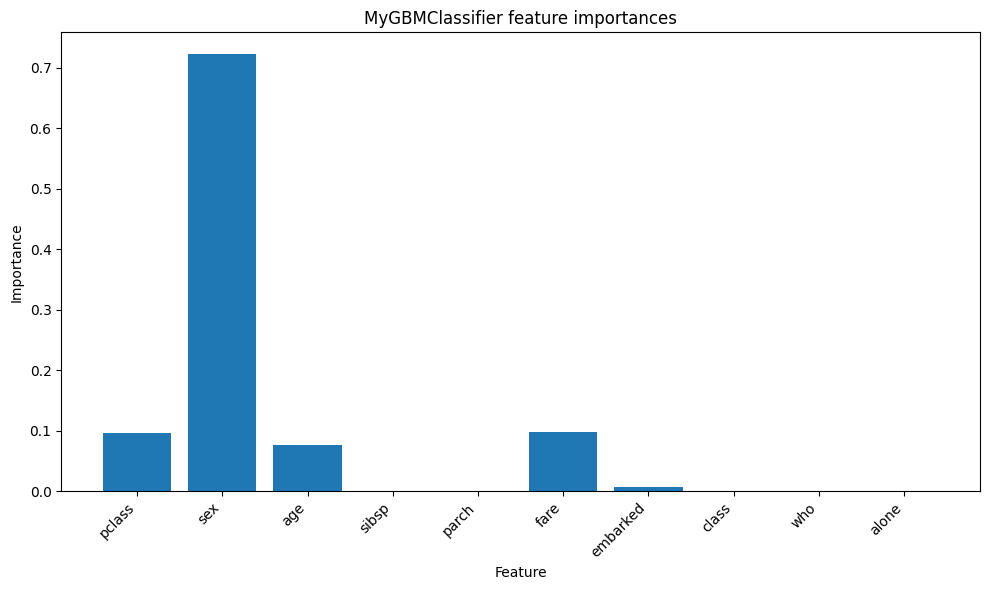

In [24]:
model = MyGBMClassifier().fit(X_train, y_train)
feature_names = features

plt.figure(figsize=(10, 6))
plt.bar(range(len(model.feature_importances_)), model.feature_importances_)
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('MyGBMClassifier feature importances')
plt.tight_layout()
plt.show()

### 5. Рекомендации по выбору ансамбля

**Градиентный бустинг (GBM / MyGBM)**  
✅ **Брать, если**:  
- Нужна простая, интерпретируемая и стабильная модель.  
- Данные небольшие/средние, важна воспроизводимость.  
- Хочется контролировать каждый шаг (остатки, learning_rate, subsample).  

❌ **Избегать, если**:  
- Требуется максимальная точность или работа с шумными/неструктурированными данными.

**XGBoost (MyXGBoost / sklearn / xgboost)**  
✅ **Брать, если**:  
- Нужна **наилучшая точность** на табличных данных (часто «золотой стандарт»).  
- Есть переобучение → используйте `reg_lambda`, `gamma`, `subsample`, `colsample`.  
- Важна скорость обучения/предсказания (оптимизированная реализация).  

❌ **Избегать, если**:  
- Нужен «белый ящик» — XGBoost сложнее интерпретировать, чем простой GBM.

**Stacking**  
✅ **Брать, если**:  
- Уже есть несколько хороших, **разнородных** моделей (например, GBM + логрег + SVM).  
- Есть достаточно данных для meta-обучения (иначе — переобучение).  
- Цель — максимизация качества, а не интерпретируемость.  

⚠️ **Важно**:  
- Используйте кросс-валидированные предсказания на 1-м уровне.  
- Meta-модель лучше простая (линейная, дерево глубины 1–3).

**Voting (Hard/Soft)**  
✅ **Брать, если**:  
- Модели **некоррелированы** и примерно одинаково хороши.  
- Нужна быстрая и устойчивая «усреднённая» модель без переобучения.  
- Soft voting особенно силён при калиброванных вероятностях (логрег, RF, GBM с `predict_proba`).  

❌ **Избегать, если**:  
- Одна модель сильно лучше остальных — тогда просто берите её.